In [180]:
import sys
import vaex
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../")
latex_img_path = "../thesis/assets/generated/"
latex_tex_path = "../thesis/tex/generated/"

from solarboat_model.utils.plot import figsize, config_matplotlib, fig_save_and_show

config_matplotlib()

# Verifying unified data alignment


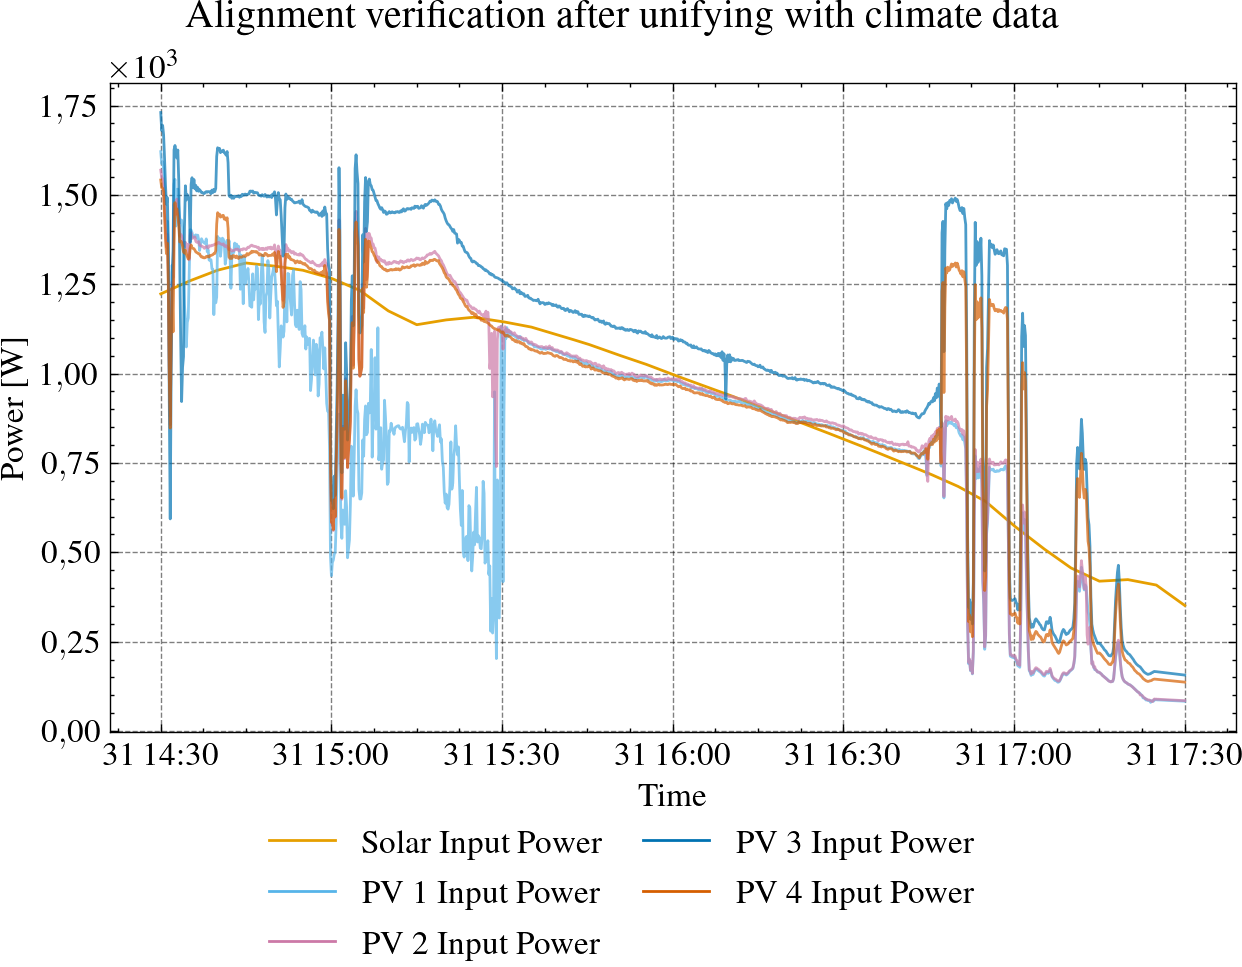

In [181]:
PERIOD = '10s'
PATH = f"../data/final/unified_monotonic_data_{PERIOD}.hdf5"

pv_S = 1.650 * 0.992
pv_eta = 0.1589
number_of_mppts = 4

t_start = pd.Timestamp("2020-01-31 14:30:00")
t_end = pd.Timestamp("2020-01-31 17:30:00")

df = vaex.open(PATH)[[
    "timestamp",
    "solcast_poa",
    *[f"MCC19_{n}__MEASUREMENTS__INPUT_VOLTAGE" for n in range(1, 1+number_of_mppts)],
    *[f"MCC19_{n}__MEASUREMENTS__INPUT_CURRENT" for n in range(1, 1+number_of_mppts)],
]].to_pandas_df()
df = df.set_index("timestamp")[t_start:t_end]

fig = plt.figure(figsize=figsize())
plt.plot(df.index, df["solcast_poa"] * pv_S, label="Solar Input Power")

for n in range(1, 1+number_of_mppts):
    mppt_input_power = df[f"MCC19_{n}__MEASUREMENTS__INPUT_VOLTAGE"] * df[f"MCC19_{n}__MEASUREMENTS__INPUT_CURRENT"] / 10
    pv_input_power = mppt_input_power / pv_eta
    plt.plot(df.index, pv_input_power, linestyle='solid', label=f"PV {n} Input Power", alpha=0.7)

plt.xlabel("Time")
plt.ylabel("Power [W]")

fig_save_and_show(
    filename=f"{latex_img_path}/climate_and_mppt_data_alignment_check.pdf",
    save_title="Verificação de alinhamento após união com dados climáticos",
    show_title="Alignment verification after unifying with climate data",
    fig=fig,
    ncol=2,
)


## Verifying the presence of the modules over time

In [182]:
PERIOD = '10s'
PATH = f"../data/final/unified_monotonic_data_{PERIOD}.hdf5"

df = vaex.open(PATH)
signatures = [c for c in df.columns if "STATE__SIGNATURE" in c]
df = df[["timestamp", *signatures]].to_pandas_df().set_index("timestamp")
df.columns = df.columns.str.replace(r"__STATE__SIGNATURE$", "", regex=True)
signatures_df = df.median().astype(np.uint8).sort_values()
print(signatures_df)
print("Numbebr of modules sending messages:", len(signatures_df))

MAM19      190
MCS19      200
MCB19_1    220
MCB19_2    221
MCC19_1    225
MCC19_2    226
MCC19_3    227
MCC19_4    228
MAB19      230
MIC19      240
MSWI19     241
MSC19_1    250
MSC19_2    251
MSC19_3    252
MSC19_4    253
MSC19_5    254
MT19       255
dtype: uint8
Numbebr of modules sending messages: 17


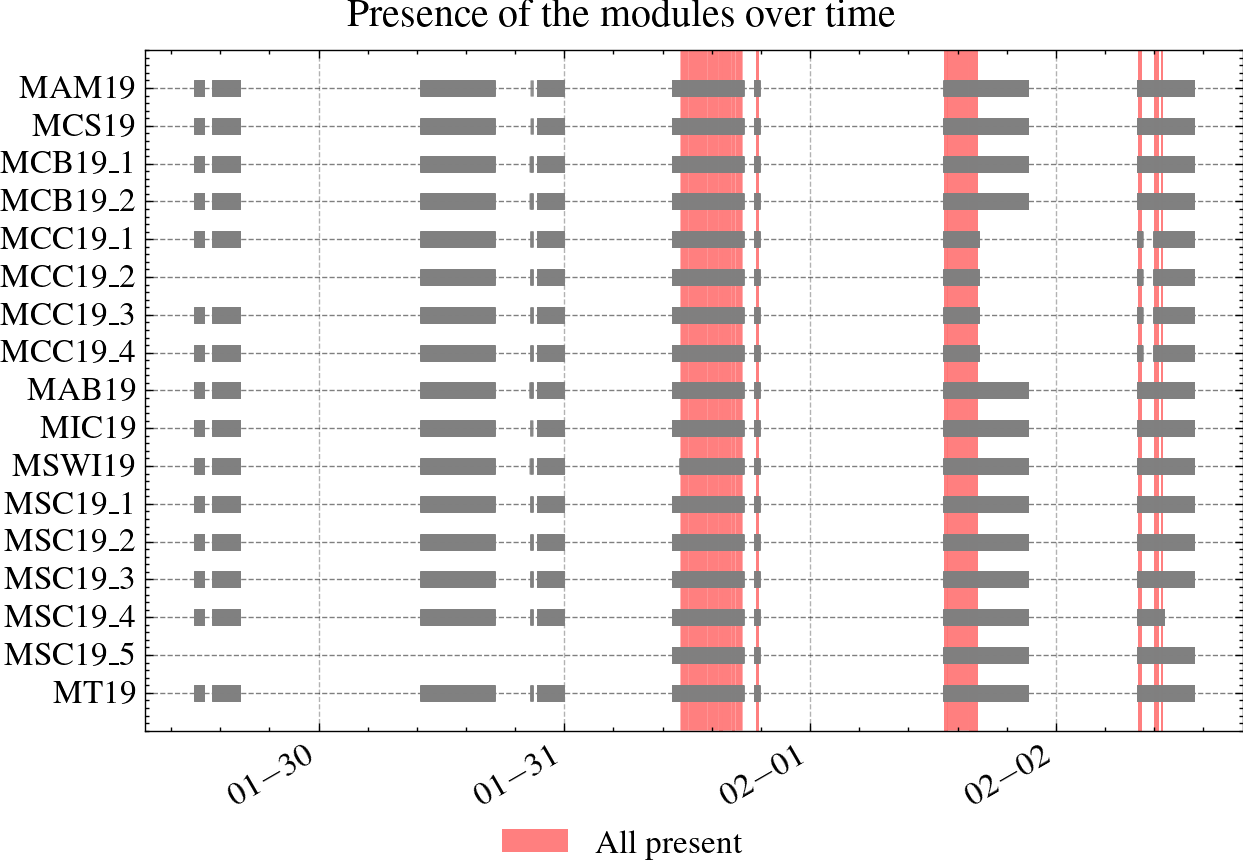

In [184]:
import matplotlib.dates as mdates

labels = signatures_df.index.tolist()
ypos = np.arange(len(labels))
fig, ax = plt.subplots(figsize=figsize())
for i, col in enumerate(labels):
    y = df[col].copy()
    mask = y.notna() & (np.isclose(y, y.median()))
    y[~mask] = np.nan
    y[mask] = ypos[i] + 0.5
    ax.scatter(df.index, y, color="gray", marker='|', alpha=0.5)

all_present = df[labels].notna().all(axis=1)
ax.fill_between(
    df.index,
    -0.5,
    len(labels) + 0.5,
    where=all_present,
    step="post",
    color="red",
    alpha=0.5,
    linewidth=0,
    zorder=0,
    label='All present'
)

ax.set_yticks(ypos + 0.5)
ax.set_yticklabels(labels)
ax.set_ylim(len(labels) + 0.5, -0.5)
ax.grid(True, axis="x", alpha=0.3)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
plt.gcf().autofmt_xdate()

fig_save_and_show(
    filename=f"{latex_img_path}/verifying_modules_presence_over_time.pdf",
    save_title="Presença dos módulos no tempo",
    show_title="Presence of the modules over time",
    fig=fig,
    ncol=2,
)
plt.show()
